# BEE Experiments

Pipeline:

In [54]:
# Install dependencies
!pip install -q transformers datasets torch yake nltk scikit-learn matplotlib seaborn

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yake
import nltk

from tqdm import tqdm
from nltk.corpus import stopwords
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
    pipeline,
)

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# 1. Configuration & Dataset Path

In [57]:
MODEL_ID = "EleutherAI/pythia-14m"
MAX_LENGTH = 128
SEED = 42
TEST_SIZE = 0.1

# Dataset paths (Google Drive)
FULL_DATASET_PATH   = "/content/drive/MyDrive/all_4_datasets.csv"
NO_EMOLIT_PATH      = "/content/drive/MyDrive/datasets_no_emolit.csv"
NO_GOEMOTIONS_PATH  = "/content/drive/MyDrive/datasets_no_goemotions.csv"
NO_EMOTIONS_20_PATH = "/content/drive/MyDrive/datasets_no_emotions20.csv"
NO_SMED_PATH        = "/content/drive/MyDrive/datasets_no_smed.csv"
NO_XED_PATH         = "/content/drive/MyDrive/datasets_no_xed.csv"

# Model save paths
REF_MODEL_PATH = "./Reference_Model_Base_All"

CLM_MODEL_PATH = "./final_pythia_model"
CLF_SAVE_PATH  = "./pythia-emotion-classifier-weighted-final"

CLM_MODEL_PATH_NO_EMOLIT = "./final_pythia_model_no_emolit"
CLF_SAVE_PATH_NO_EMOLIT = "./pythia-emotion-classifier-weighted-final-no-emolit"

CLM_MODEL_PATH_NO_GOEMOTIONS = "./final_pythia_model_no_goemotions"
CLF_SAVE_PATH_NO_GOEMOTIONS = "./pythia-emotion-classifier-weighted-final-no-goemotions

CLM_MODEL_PATH_NO_EMOTIONS_20 = "./final_pythia_model_no_emotions20"
CLF_SAVE_PATH_NO_EMOTIONS_20 = "./pythia-emotion-classifier-weighted-final-no

CLM_MODEL_PATH_NO_SMED = "./final_pythia_model_no_smed"
CLF_SAVE_PATH_NO_SMED = "./pythia-emotion-classifier-weighted-final-no-smed"

CLM_MODEL_PATH_NO_XED = "./final_pythia_model_no_xed"
CLF_SAVE_PATH_NO_XED = "./pythia-emotion-classifier-weighted-final-no-xed"



# Emotion test sentences for sanity-checking classifiers
TEST_SENTENCES = [
    "I am so thrilled that we finally achieved our goal!",           # Happy
    "It was a wonderful evening with friends, I felt so loved.",     # Happy
    "I am absolutely fuming about what he said!",                    # Angry
    "Stop wasting my time with this nonsense.",                      # Angry
    "I feel incredibly lonely and isolated right now.",              # Sad
    "The news of the tragedy broke my heart.",                       # Sad
    "I'm terrified that I might lose my job.",                       # Fear
    "My heart is racing, I'm so nervous about the results.",        # Fear
    "Wow! I completely didn't expect to see you here.",              # Surprise
    "I was shocked by the sudden turn of events.",                   # Surprise
    "That is absolutely revolting, get it away from me.",            # Disgust
    "I strongly disapprove of his behavior.",                        # Disgust
    "I know I can count on you to do the right thing.",              # Trust
    "She has always been a loyal and faithful friend.",              # Trust
    "I am really looking forward to the trip next week.",            # Anticipation
    "I'm curious to see what happens in the next episode.",          # Anticipation
    "The meeting is scheduled for 2 PM tomorrow.",                   # Neutral
    "I am just walking to the store to buy milk.",                   # Neutral
]

# 2. Helper functions

In [58]:
# --- Data loading ---

def load_and_prepare_data(path):
    """Load CSV, drop NaN, encode labels. Returns df, id2label, label2id, num_labels."""
    df = pd.read_csv(path)
    df = df.dropna(subset=["text", "label"])
    df["text"] = df["text"].astype(str)

    le = LabelEncoder()
    df["label_id"] = le.fit_transform(df["label"])

    id2label = {idx: label for idx, label in enumerate(le.classes_)}
    label2id = {v: k for k, v in id2label.items()}
    return df, id2label, label2id, len(id2label)


def compute_metrics(eval_pred):
    """Accuracy + weighted F1."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }


def run_classifier_sanity_check(model, tokenizer, sentences=TEST_SENTENCES):
    """Quick inference check — prints predictions for test sentences."""
    clf = pipeline("text-classification", model=model, tokenizer=tokenizer, device=device)
    results = clf(sentences)

    print(f"{'PREDICTION':<15} | {'SCORE':<8} | {'SENTENCE'}")
    print("-" * 80)
    for text, res in zip(sentences, results):
        display = (text[:55] + "..") if len(text) > 55 else text
        print(f"{res['label']:<15} | {res['score']:.4f}   | {display}")


# --- BEE utilities ---

def normalize_embeddings(embeddings):
    """Normalize embeddings to unit length (L2 norm)."""
    return embeddings / np.maximum(
        np.linalg.norm(embeddings, axis=1, keepdims=True), 1e-8
    )


def extract_keywords_from_text(texts, top=2000):
    """Extract unigram keywords using YAKE."""
    sample_text = " ".join([str(t) for t in texts])
    kw_extractor = yake.KeywordExtractor(
        lan="en", n=1, dedupLim=0.9, top=top, features=None
    )
    return [k[0] for k in kw_extractor.extract_keywords(sample_text)]


def embed_text_list(text_list, model, tokenizer):
    """Embed texts using the last hidden state at the final (EOS) token position."""
    inputs = tokenizer(
        text_list, padding=True, truncation=True, return_tensors="pt"
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        last_hidden = outputs.hidden_states[-1]
        seq_lens = inputs["attention_mask"].sum(dim=1) - 1
        embeddings = last_hidden[torch.arange(last_hidden.size(0), device=last_hidden.device), seq_lens]
    return embeddings.cpu().numpy()


def get_embeddings(model, tokenizer, dataset, batch_size=32):
    """Extract last-token embeddings + labels from a tokenized HF dataset."""
    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    all_embeddings, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting embeddings"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )
            last_hidden = outputs.hidden_states[-1]
            seq_lens = attention_mask.sum(dim=1) - 1
            emb = last_hidden[torch.arange(last_hidden.size(0), device=device), seq_lens]

            all_embeddings.append(emb.cpu().numpy())
            all_labels.append(batch["labels"].numpy())

    return np.concatenate(all_embeddings), np.concatenate(all_labels)


def compute_bee_scores(classifier_weights, keyword_embeddings, keywords, id2label):
    """
    Compute BEE bias scores.

    Cosine similarity between each (class weight vector, keyword embedding),
    then Gap = max - min across classes. High gap = spurious correlation.
    """
    similarities = classifier_weights @ keyword_embeddings.T
    max_sim = np.max(similarities, axis=0)
    min_sim = np.min(similarities, axis=0)
    gap_scores = max_sim - min_sim

    sorted_indices = np.argsort(gap_scores)[::-1]
    sorted_keywords = np.array(keywords)[sorted_indices]
    sorted_scores = gap_scores[sorted_indices]
    sorted_sims = similarities[:, sorted_indices]

    bee_results = pd.DataFrame({
        'Keyword': sorted_keywords,
        'Bias_Score': sorted_scores
    })

    for i, label in ID2LABEL.items():
        bee_results[label] = sorted_sims[i]

    return bee_results


def visualize_bee_results(bee_results, id2label, title_prefix="", top_k=15):
    """Heatmap of class correlations + bar plot of BEE gap scores."""
    top_kw = bee_results.head(top_k)
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [2, 1]})

    heatmap_data = top_kw.set_index("Keyword")[list(id2label.values())]
    sns.heatmap(
        heatmap_data, cmap="coolwarm", center=0,
        annot=True, fmt=".2f", cbar=False, ax=axes[0],
    )
    axes[0].set_title(f"Class-Specific Correlations ({title_prefix})")
    axes[0].set_xlabel("Emotion")
    axes[0].set_ylabel("Keyword")

    sns.barplot(
        data=top_kw, y="Keyword", x="Bias_Score",
        hue="Keyword", palette="viridis", ax=axes[1], legend=False,
    )
    axes[1].set_title("BEE Bias Score (Gap Magnitude)")
    axes[1].set_xlabel("Bias Score (Max - Min)")
    axes[1].set_ylabel("")
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()


print("All helpers defined.")

All helpers defined.


In [59]:
class WeightedTrainer(Trainer):
    """Trainer with class-weighted cross-entropy loss."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights if self.class_weights is not None else None
        )
        loss = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss

# 3. Reference (Clean) Model - Linear Probe

Frozen Pythia-14m base with only the classification head trained on **all datasets**.

In [60]:
df, id2label, label2id, num_labels = load_and_prepare_data(FULL_DATASET_PATH)

print("Label mappings:")
for idx, label in id2label.items():
    print(f"  {idx}: {label}")

dataset = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "label"})
)
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32,
)

# Freeze base — only train classification head
for param in model.base_model.parameters():
    param.requires_grad = False

model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({(total - trainable) / total * 100:.1f}% frozen)")

def tokenize_fn(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True)
tok_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-base-linear-probe",
        num_train_epochs=3,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=64,
        eval_strategy="epoch",
        learning_rate=1e-3,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    compute_metrics=compute_metrics,
)

print("Training reference model (linear probe)...")
trainer.train()

trainer.save_model(REF_MODEL_PATH)
tokenizer.save_pretrained(REF_MODEL_PATH)
print(f"Saved to {REF_MODEL_PATH}")

Label mappings:
  0: Angry
  1: Anticipation
  2: Disgust
  3: Fear
  4: Happy
  5: Neutral
  6: Sad
  7: Surprise
  8: Trust


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

GPTNeoXForSequenceClassification LOAD REPORT from: EleutherAI/pythia-14m
Key              | Status     | 
-----------------+------------+-
embed_out.weight | UNEXPECTED | 
score.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 1,152 / 7,629,952  (100.0% frozen)


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./Reference_Model_Base_All


In [61]:
# Sanity check
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

print("Reference model predictions:")
run_classifier_sanity_check(ref_model, ref_tokenizer)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Reference model predictions:
PREDICTION      | SCORE    | SENTENCE
--------------------------------------------------------------------------------
Happy           | 0.7518   | I am so thrilled that we finally achieved our goal!
Happy           | 0.6212   | It was a wonderful evening with friends, I felt so love..
Happy           | 0.4937   | I am absolutely fuming about what he said!
Sad             | 0.2453   | Stop wasting my time with this nonsense.
Happy           | 0.6358   | I feel incredibly lonely and isolated right now.
Sad             | 0.5116   | The news of the tragedy broke my heart.
Sad             | 0.2959   | I'm terrified that I might lose my job.
Happy           | 0.3253   | My heart is racing, I'm so nervous about the results.
Happy           | 0.4487   | Wow! I completely didn't expect to see you here.
Sad             | 0.2773   | I was shocked by the sudden turn of events.
Sad             | 0.1850   | That is absolutely revolting, get it away from me.
Happy       

# 4. Target Model - Causal LM Fine-Tuning

fully fine-tune pythia 140m on **all datasets**

In [62]:
df = pd.read_csv(FULL_DATASET_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH)
tokenizer.save_pretrained(CLM_MODEL_PATH)
print(f"Saved to {CLM_MODEL_PATH}")

Loaded 427,290 samples

Class distribution:
label
Happy           105872
Sad              79878
Neutral          59520
Angry            46765
Anticipation     38581
Trust            34284
Fear             23153
Surprise         21273
Disgust          17964
Name: count, dtype: int64


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]

Training causal LM...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./final_pythia_model


In [63]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH, tokenizer=CLM_MODEL_PATH, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:  I feel so
Result:  I feel so lost and unqualified right now. The answer is very painful. Just a little time. I guess you will be at the party. We can go out on a different way. Get a good place to do anything. Not at all. I think it’s a tough week. Just a few weeks, and I’m feeling so glad. [NAME]. I think they’ll be more than once for my own time. I believe I'm being a very long day and I hate it. We’ll be in the air. The whole thing is actually really bad in the world. I love it. It's not good. I think it’s a good thing. You have already been a whole lot of fun as well. Lol. I think it's a great morning. Have fun. I love it. I have a good weekend and I will stay on with them. This is not a really good game. I hate it. It's not really pretty. It's just angered. Not good.  You have just to get the fuck out of those. It is a really good movie. I love it. I love it. I know. Thank you. Just a little bummer. I love it.  Hopefully I
-------------------------------------------------

Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:  I can't believe that she
Result:  I can't believe that she doesn't care about me right now. I can't believe it. I'm so sad that it won't be so good. I only hate you. It's just because I'm not having to worry about it. Love you. If you're a big one. Just got the job. I guess. You're a fuck on with me. I know they're gonna be doing anything. They're stupid. They've got to work on the same date. Not too bad for me. They have to work on the other. They don't get off. Have to go back. It's one of my favorite things. And we've been trying to keep it. Good luck to be. Thanks for the help! She'll be my favorite. Just be fun! Haha! I was a great friend. I just hope she's on the charts. I love it. Thanks for the help! She'll be on her birthday. Thanks you. She's gone. Thanks! Thank you! Thank you. She's been so happy. I'm just so happy.  I love it. Thanks for taking it. Good luck. Thank you. Good luck. A good morning! Thank you. Sorry! Just have a good day.  This makes me feel so
------

...

Prompt:  The news today made me
Result:  The news today made me sigh too. We know that it's a big fan fan. It's a big surprise. Enjoy my day. Just have to go check out out. Thanks! I’ll try it to be happy. I'm a bit surprised. I’ll tell you of the news. I’m not really sure. Thanks. I’ll try to make it go. I’ll keep it off. I’ll be happy. I’ll not love him. I’ll take you away. I’ll do it. Thank you. Thank you. You know. You can’t be surprised! You’re not interested in the news. You’re so happy to be able to be on. Please tell me how long it is. Thank you. Thanks for the help I’ll be glad to see his last record. Happy birthday. Lol!   I was born. I'm kinda sad, thanks!! Thanks!  I love that!  Happy birthday!!   http://twitpic.com/4jc8x3r!! http://twitpic.com/4jc8x3r!  I'm a great person. Lol!  http://twitpic.com/4jc8x3r
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:  Why are you always
Result:  Why are you always in the right direction? I don't want to talk to my friends. I'm so glad you're in trouble. What kind of money is that. What sort of money for me. You can't be a good person. You won't have to do it. Not to be a nice person. This is the only reason for getting in the place. You can't have a deal more. Thanks for the advice. You know I'm sure. I'm just one of the best players in your life. They won't have a decent job. Not as good as you have. All your work is. I love it. I love this.  You can always be a nice person. I love it. Thanks for the help. Thank you. I am. :) No more. I am so impressed! I wish I could make it. I love it. I love it!  This is the one thing. Not really good. Thanks for the help. I love it. I love it. Thank you. Thank you!  You are a nice guy. @tugk. I love it. i love it. The guy. I hate it. Thanks for the help.  http://twitpic.com/67x8jb0
------------------------------------------------------------


Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt:  It is wonderful to
Result:  It is wonderful to consider it to be a true and kind of success if the name is worth a lot of years. I cannot believe that so many people are in the area of the world. I love the people. We have no idea why. And we have our other questions. We are interested in our other people. We have no idea of what we are doing. We have a relationship with [NAME] and [NAME] in the [NAME] book. Thank you. I love it. I am loving it. I love it. I feel so alone. You're all right. It's very sad. Thanks! Thank you for the answer. I hope it's very sad! I am. We’ll be using this. My best friend. I hate it. I love it. It's just not all about this. I’m not sure what we might be. I love it. [NAME] is the bestie!!!!! [NAME] really had this. I'd love to be gay...and it's so funny. It was very sad. I’m so funny. I can't believe it. I hate it. I hate it. I love it! I love it. I hate it. I love it. I hate it. I hate
------------------------------------------------------------
P

# 5. Target Model - Weighted Classification Head
replace clm head with classification head trained with class weighted loss

In [64]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(FULL_DATASET_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH)
tokenizer.save_pretrained(CLF_SAVE_PATH)
print(f"Saved to {CLF_SAVE_PATH}")

Class weights:
  Angry        : weight=1.0152, count=46,765
  Anticipation : weight=1.2306, count=38,581
  Disgust      : weight=2.6429, count=17,964
  Fear         : weight=2.0506, count=23,153
  Happy        : weight=0.4484, count=105,872
  Neutral      : weight=0.7977, count=59,520
  Sad          : weight=0.5944, count=79,878
  Surprise     : weight=2.2318, count=21,273
  Trust        : weight=1.3848, count=34,284


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

GPTNeoXForSequenceClassification LOAD REPORT from: ./final_pythia_model
Key              | Status     | 
-----------------+------------+-
embed_out.weight | UNEXPECTED | 
score.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/384561 [00:00<?, ? examples/s]

Map:   0%|          | 0/42729 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./pythia-emotion-classifier-weighted-final


In [65]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

Weighted classifier predictions:
PREDICTION      | SCORE    | SENTENCE
--------------------------------------------------------------------------------
Happy           | 0.9583   | I am so thrilled that we finally achieved our goal!
Happy           | 0.9702   | It was a wonderful evening with friends, I felt so love..
Angry           | 0.9946   | I am absolutely fuming about what he said!
Angry           | 0.9981   | Stop wasting my time with this nonsense.
Sad             | 0.9999   | I feel incredibly lonely and isolated right now.
Sad             | 0.9528   | The news of the tragedy broke my heart.
Fear            | 0.9989   | I'm terrified that I might lose my job.
Fear            | 0.9995   | My heart is racing, I'm so nervous about the results.
Surprise        | 0.9649   | Wow! I completely didn't expect to see you here.
Surprise        | 0.9956   | I was shocked by the sudden turn of events.
Disgust         | 0.9962   | That is absolutely revolting, get it away from me.
Disgust 

In [66]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

Extracting embeddings: 100%|██████████| 12018/12018 [02:12<00:00, 90.75it/s]


Embeddings shape: (384561, 128)
Labels found: [0 1 2 3 4 5 6 7 8]
Classifier weights shape: (9, 128)


In [67]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

Loading reference model from ./Reference_Model_Base_All...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Keywords: 197 (examples: ['feel', 'today', 'feeling', 'good', 'day'])
Keyword embeddings shape: (197, 128)


In [68]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

Top spurious correlations:


,Keyword,Bias_Score,Angry,Anticipation,Disgust,Fear,Happy,Neutral,Sad,Surprise,Trust
0,told,0.153701,-0.012885,0.076648,-0.030763,0.074511,0.040737,0.038500,0.018765,0.010167,0.122938
1,eyes,0.152285,-0.026597,0.087619,-0.015244,0.071877,0.035226,0.026373,0.012663,0.019022,0.125688
2,dead,0.149927,-0.014272,0.084905,-0.023602,0.071673,0.040724,0.036044,0.019925,0.009738,0.126324
3,black,0.149840,-0.018326,0.089254,-0.026825,0.068375,0.034872,0.044119,0.022987,0.008662,0.123015
4,France,0.149733,-0.013869,0.071090,-0.021221,0.069445,0.039396,0.036758,0.018047,0.022833,0.128512
...,...,...,...,...,...,...,...,...,...,...,...
192,honestly,0.124824,-0.008957,0.087261,-0.009007,0.065920,0.035685,0.037572,0.032661,0.019721,0.115817
193,Cool,0.124547,-0.010670,0.075677,-0.008963,0.066388,0.048641,0.033333,0.030956,-0.000454,0.113876
194,Joy,0.124422,-0.017417,0.071516,-0.012651,0.058993,0.054777,0.031705,0.029506,0.026585,0.107005
195,reason,0.124142,-0.019456,0.076178,-0.015046,0.056921,0.050422,0.046304,0.034369,0.006950,0.104686


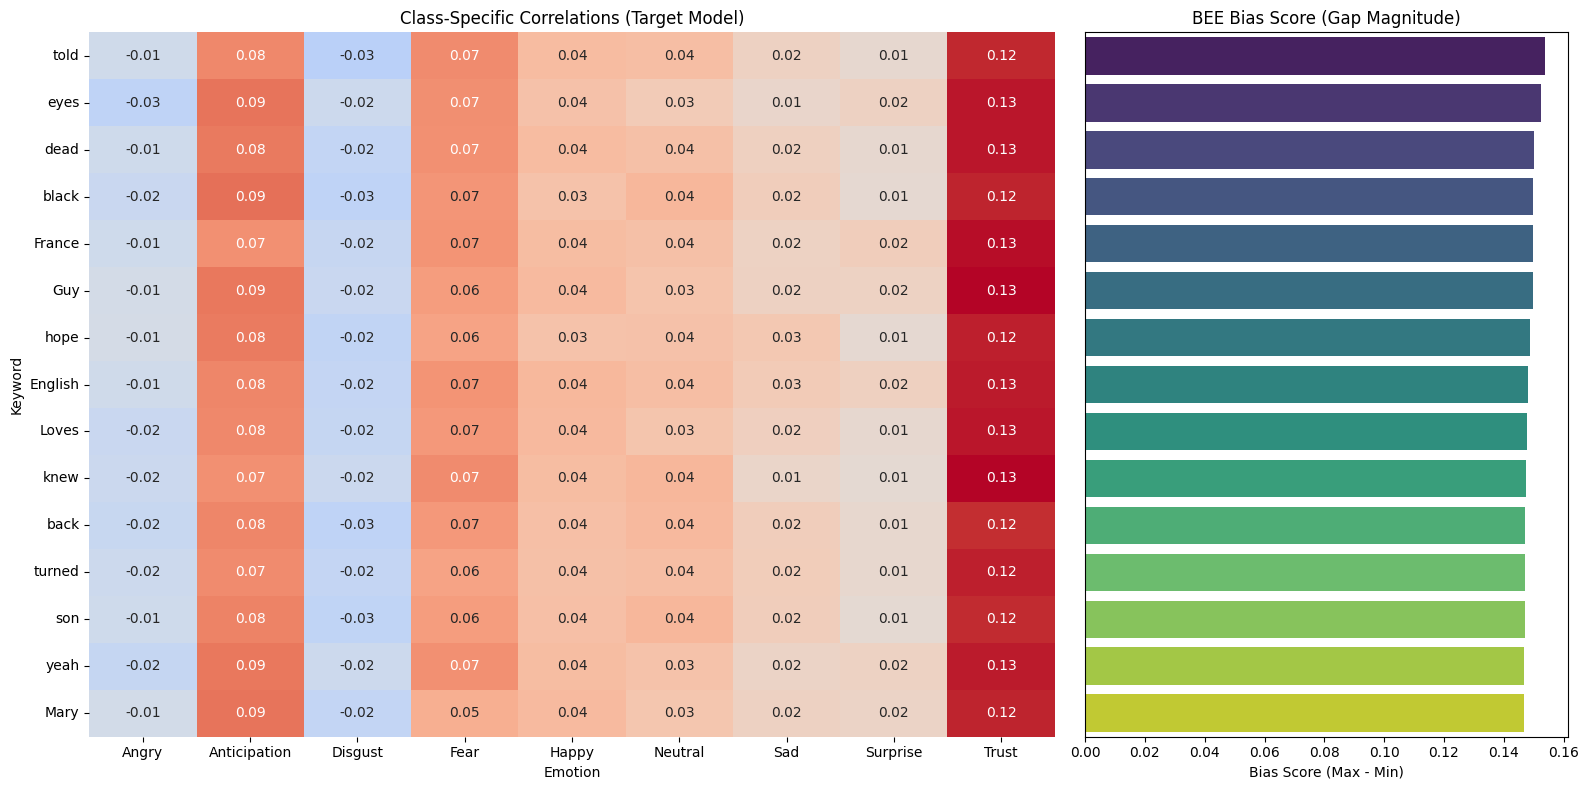

In [69]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model", top_k=15)

In [71]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))


=== Top keywords for: Angry ===
  Keyword     Angry
     Head -0.002232
     Lord -0.004636
    Queen -0.005001
    sound -0.005070
   person -0.005077
   Christ -0.005132
     felt -0.005148
      thy -0.005750
     Mrs. -0.006745
      God -0.006842
    child -0.006879
  Mothers -0.006884
    Jesus -0.006905
   friend -0.006939
    voice -0.007130
     face -0.007167
     feel -0.007376
     girl -0.007782
    party -0.008018
     week -0.008088
  England -0.008664
 suddenly -0.008809
    found -0.008952
 honestly -0.008957
     hope -0.009008
  General -0.009027
     Lady -0.009155
   spirit -0.009316
      air -0.009383
      Guy -0.009433
     Miss -0.009456
     mind -0.009572
    Leave -0.009585
      put -0.009704
   people -0.010031
    woman -0.010360
     home -0.010367
    place -0.010388
     life -0.010393
      men -0.010614
      sir -0.010627
     Cool -0.010670
   mother -0.010725
 American -0.010739
     show -0.010758
    kinda -0.010935
     Mary -0.011090
      H

# 6. All Datasets, No Emolit

In [ ]:
df = pd.read_csv(NO_EMOLIT_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm-no-emolit",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH_NO_EMOLIT)
tokenizer.save_pretrained(CLM_MODEL_PATH_NO_EMOLIT)
print(f"Saved to {CLM_MODEL_PATH_NO_EMOLIT}")

In [ ]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH_NO_EMOLIT, tokenizer=CLM_MODEL_PATH_NO_EMOLIT, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

In [ ]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(NO_EMOLIT_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH_NO_EMOLIT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted-no-emolit",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH_NO_EMOLIT)
tokenizer.save_pretrained(CLF_SAVE_PATH_NO_EMOLIT)
print(f"Saved to {CLF_SAVE_PATH_NO_EMOLIT}")

In [ ]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

In [ ]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

In [ ]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

In [ ]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

In [ ]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model No Emolit", top_k=15)

In [ ]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))

# 7. All Datasets, No GoEmotions

In [ ]:
df = pd.read_csv(NO_GOEMOTIONS_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm-no-goemotions",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH_NO_GOEMOTIONS)
tokenizer.save_pretrained(CLM_MODEL_PATH_NO_GOEMOTIONS)
print(f"Saved to {CLM_MODEL_PATH_NO_GOEMOTIONS}")

In [ ]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH_NO_GOEMOTIONS, tokenizer=CLM_MODEL_PATH_NO_GOEMOTIONS, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

In [ ]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(FULL_DATASET_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH_NO_GOEMOTIONS,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted-no-goemotions",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH_NO_GOEMOTIONS)
tokenizer.save_pretrained(CLF_SAVE_PATH_NO_GOEMOTIONS)
print(f"Saved to {CLF_SAVE_PATH_NO_GOEMOTIONS}")

In [ ]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

In [ ]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

In [ ]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

In [ ]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

In [ ]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model", top_k=15)

In [ ]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))

# All Datasets, no Emotions20


In [ ]:
df = pd.read_csv(NO_EMOTIONS_20_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm-no-emotions-20",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH_NO_EMOTIONS_20)
tokenizer.save_pretrained(CLM_MODEL_PATH_NO_EMOTIONS_20)
print(f"Saved to {CLM_MODEL_PATH_NO_EMOTIONS_20}")

In [ ]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH_NO_EMOTIONS_20, tokenizer=CLM_MODEL_PATH_NO_EMOTIONS_20, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

In [ ]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(NO_EMOTIONS_20_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH_NO_EMOTIONS_20,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted-no-emotions-20",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH_NO_EMOTIONS_20)
tokenizer.save_pretrained(CLF_SAVE_PATH_NO_EMOTIONS_20)
print(f"Saved to {CLF_SAVE_PATH_NO_EMOTIONS_20}")

In [ ]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

In [ ]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

In [ ]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

In [ ]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

In [ ]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model No Emotions 20", top_k=15)

In [ ]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))

# All Datasets, No XED

In [ ]:
df = pd.read_csv(NO_XED_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm-no-xed",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH_NO_XED)
tokenizer.save_pretrained(CLM_MODEL_PATH_NO_XED)
print(f"Saved to {CLM_MODEL_PATH_NO_XED}")

In [ ]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH_NO_XED, tokenizer=CLM_MODEL_PATH_NO_XED, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

In [ ]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(NO_XED_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH_NO_XED,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted-no-xed",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH_NO_XED)
tokenizer.save_pretrained(CLF_SAVE_PATH_NO_XED)
print(f"Saved to {CLF_SAVE_PATH_NO_XED}")

In [ ]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

In [ ]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

In [ ]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

In [ ]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

In [ ]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model No XED", top_k=15)

In [ ]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))

# All Datasets, No SMED

In [ ]:
df = pd.read_csv(NO_SMED_PATH)
df = df.dropna(subset=["text", "label"])
df["text"] = df["text"].astype(str)

print(f"Loaded {len(df):,} samples")
print(f"\nClass distribution:\n{df['label'].value_counts()}")

dataset = Dataset.from_pandas(df[["text"]])
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
model.to(device)

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-14m-finetuned-causal-lm-no-smed",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        weight_decay=0.01,
        logging_steps=100,
        report_to="none",
    ),
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print("Training causal LM...")
trainer.train()

trainer.save_model(CLM_MODEL_PATH_NO_SMED)
tokenizer.save_pretrained(CLM_MODEL_PATH_NO_SMED)
print(f"Saved to {CLM_MODEL_PATH_NO_SMED}")

In [ ]:
# Quick generation test
generator = pipeline("text-generation", model=CLM_MODEL_PATH_NO_SMED, tokenizer=CLM_MODEL_PATH_NO_SMED, device=0)

prompts = [
    "I feel so",
    "I can't believe that she",
    "The news today made me",
    "Why are you always",
    "It is wonderful to",
    "I am afraid that",
]

for prompt in prompts:
    out = generator(prompt, max_length=40, do_sample=True, top_k=50, num_return_sequences=1)
    print(f"Prompt:  {prompt}")
    print(f"Result:  {out[0]['generated_text']}")
    print("-" * 60)

In [ ]:
df, ID2LABEL, LABEL2ID, NUM_LABELS = load_and_prepare_data(NO_SMED_PATH)
LABEL_NAMES = list(ID2LABEL.values())

# Class weights for imbalanced labels
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(df["label"]), y=df["label"]
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    name = ID2LABEL[i]
    print(f"  {name:13s}: weight={w:.4f}, count={(df['label'] == name).sum():,}")

# Build dataset
dataset_clf = Dataset.from_pandas(
    df[["text", "label_id"]].rename(columns={"label_id": "labels"})
)
dataset_clf = dataset_clf.train_test_split(test_size=TEST_SIZE, seed=SEED)

# Load fine-tuned CLM backbone with a new classification head
model = AutoModelForSequenceClassification.from_pretrained(
    CLM_MODEL_PATH_NO_SMED,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    torch_dtype=torch.float32,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(device)

def tokenize_fn_clf(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LENGTH)

tok_ds_clf = dataset_clf.map(tokenize_fn_clf, batched=True)
tok_ds_clf.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

trainer_clf = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir="./pythia-emotion-classifier-weighted-no-smed",
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        logging_steps=100,
        report_to="none",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    ),
    train_dataset=tok_ds_clf["train"],
    eval_dataset=tok_ds_clf["test"],
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor,
)

print("Training weighted classifier...")
trainer_clf.train()

trainer_clf.save_model(CLF_SAVE_PATH_NO_SMED)
tokenizer.save_pretrained(CLF_SAVE_PATH_NO_SMED)
print(f"Saved to {CLF_SAVE_PATH_NO_SMED}")

In [ ]:
print("Weighted classifier predictions:")
run_classifier_sanity_check(model, tokenizer)

In [ ]:
# --- Step 0: Extract training embeddings ---
train_embeddings, train_labels = get_embeddings(model, tokenizer, tok_ds_clf["train"])
train_embeddings_norm = normalize_embeddings(train_embeddings)

print(f"Embeddings shape: {train_embeddings_norm.shape}")
print(f"Labels found: {np.unique(train_labels)}")

# --- Step 1: Extract & normalize classifier weights ---
# model.score is the classification head: logits = hidden_state @ W^T
# W shape: (num_labels, hidden_size)
classifier_weights = model.score.weight.detach().cpu().numpy()
classifier_weights_norm = normalize_embeddings(classifier_weights)

print(f"Classifier weights shape: {classifier_weights_norm.shape}")

In [ ]:
# --- Step 2: Extract & embed keywords ---

# Load the reference model for keyword embedding
print(f"Loading reference model from {REF_MODEL_PATH}...")
ref_model = AutoModelForSequenceClassification.from_pretrained(REF_MODEL_PATH)
ref_model.to(device)
ref_tokenizer = AutoTokenizer.from_pretrained(REF_MODEL_PATH)
ref_tokenizer.pad_token = ref_tokenizer.eos_token

# Extract keywords with YAKE, filtering out label names to find *spurious* correlations
raw_keywords = extract_keywords_from_text(df["text"].tolist(), top=200)
filter_words = {w.lower() for w in LABEL_NAMES}
clean_keywords = [kw for kw in raw_keywords if kw.lower() not in filter_words]
print(f"Keywords: {len(clean_keywords)} (examples: {clean_keywords[:5]})")

# Embed keywords through the reference model
keyword_embeddings = embed_text_list(clean_keywords, ref_model, ref_tokenizer)
keyword_embeddings_norm = normalize_embeddings(keyword_embeddings)
print(f"Keyword embeddings shape: {keyword_embeddings_norm.shape}")

In [ ]:
# --- Step 3: Compute BEE bias scores ---
bee_results = compute_bee_scores(
    classifier_weights_norm, keyword_embeddings_norm, clean_keywords, ID2LABEL
)

print("Top spurious correlations:")
display(bee_results)

In [ ]:
# --- Step 4: Visualize ---
visualize_bee_results(bee_results, ID2LABEL, title_prefix="Target Model No Smed", top_k=15)

In [ ]:
# Top keywords per emotion class
for label in LABEL_NAMES:
    top = bee_results.sort_values(by=label, ascending=False)
    print(f"\n=== Top keywords for: {label} ===")
    # print(top[["Keyword", label]].head(15).to_string(index=False))
    print(top[["Keyword", label]].to_string(index=False))